# Solana DEX data: a first lookFour questions answered against the live [OnchainDivers](https://onchaindivers.com)ClickHouse database. The SQL is the same as in[`queries/solana`](../queries/solana); the output below is committed, so you canread this without credentials.Data ran on 11 September 2026.

In [ ]:
import osimport clickhouse_connectimport matplotlib.pyplot as pltclient = clickhouse_connect.get_client(    host=os.environ["CLICKHOUSE_HOST"],    port=int(os.environ.get("CLICKHOUSE_PORT", "8123")),    username=os.environ["CLICKHOUSE_USERNAME"],    password=os.environ["CLICKHOUSE_PASSWORD"],)

## 1. Where the volume actually isThree venues, thirty days, SOL-quoted trades only. Meteora needs the`swap_for_y` flag: its amount columns hold the input and output of the traderather than fixed sides of the pair, so summing the quote column blindly treatsa token amount as lamports on half the rows.

In [ ]:
df = client.query_df("""SELECT *FROM(    SELECT 'pumpfun' AS venue,           toDate(block_time) AS day,           count()            AS swaps,           round(sum(quote_coin_amount) / 1e9, 1) AS sol_volume    FROM pumpfun_all_swaps    WHERE block_time > now() - INTERVAL 30 DAY    GROUP BY day    UNION ALL    SELECT 'pumpswap',           toDate(block_time),           count(),           round(sum(quote_token_amount) / 1e9, 1)    FROM pumpswap_all_swaps    WHERE block_time > now() - INTERVAL 30 DAY      AND quote_token = 'So11111111111111111111111111111111111111112'    GROUP BY toDate(block_time)    UNION ALL    SELECT 'meteora',           toDate(block_time),           count(),           round(sum(toUInt128(if(swap_for_y = 1, quote_coin_amount, base_coin_amount))) / 1e9, 1)    FROM meteora_swaps    WHERE block_time > now() - INTERVAL 30 DAY      AND quote_coin = 'So11111111111111111111111111111111111111112'    GROUP BY toDate(block_time))ORDER BY day, venue""")df.head()

venue,day,swaps,sol_volume
meteora,2026-08-12,265084,342101.8
pumpfun,2026-08-12,1790040,789903.6
pumpswap,2026-08-12,3839602,2042880.6
meteora,2026-08-13,519185,607105.2
pumpfun,2026-08-13,3567612,1602674.9


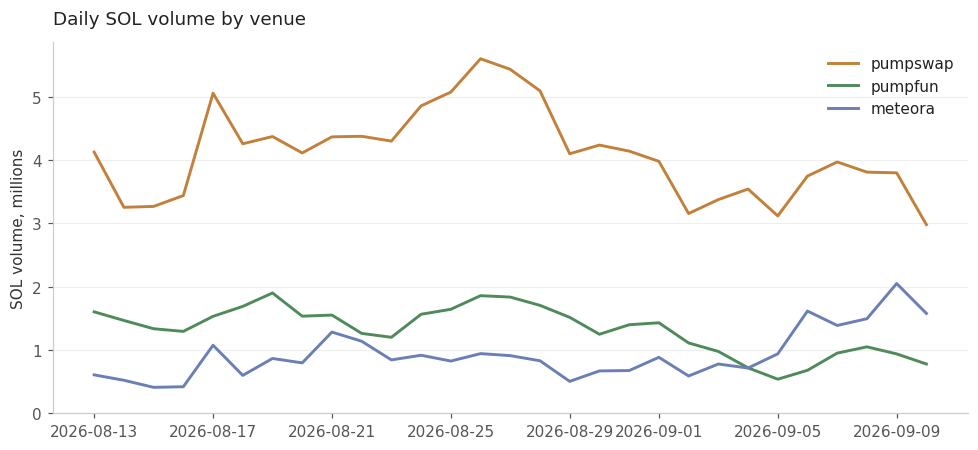

In [ ]:
piv = df.pivot(index="day", columns="venue", values="sol_volume")piv = piv.iloc[1:-1]          # first and last days of the window are partialax = (piv / 1e6).plot(figsize=(9, 4.2), lw=1.9)ax.set_ylabel("SOL volume, millions")ax.set_ylim(bottom=0)

PumpSwap carries roughly three times Pump.fun and five times Meteora on a medianday. The gap is stable across the month, so this is structure rather than aspike: bonding-curve launches feed the AMM, and the AMM is where size trades.

## 2. Median and tail move apartA single average trade size hides the thing you care about. Splitting thedistribution shows two different populations sharing one venue.

In [ ]:
df = client.query_df("""SELECT    toDate(block_time)                                    AS day,    count()                                               AS swaps,    round(quantile(0.5)(quote_token_amount)  / 1e9, 3)    AS p50_sol,    round(quantile(0.9)(quote_token_amount)  / 1e9, 3)    AS p90_sol,    round(quantile(0.99)(quote_token_amount) / 1e9, 3)    AS p99_sol,    round(max(quote_token_amount)            / 1e9, 2)    AS max_solFROM pumpswap_all_swapsWHERE block_time > now() - INTERVAL 14 DAY  AND quote_token = 'So11111111111111111111111111111111111111112'GROUP BY dayORDER BY day""")df.head()

day,swaps,p50_sol,p90_sol,p99_sol,max_sol
2026-08-28,5555667,0.047,0.857,5.316,12394.40
2026-08-29,10309773,0.038,0.835,4.739,11102.31
2026-08-30,10882403,0.012,0.721,5.192,9392.25
2026-08-31,12245368,0.007,0.634,4.089,10592.39
2026-09-01,12402842,0.004,0.556,4.486,13971.16


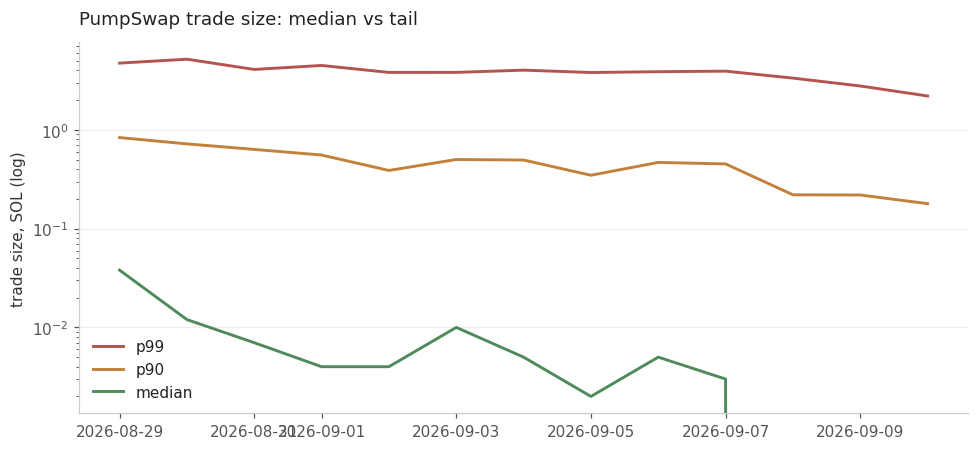

In [ ]:
d = df.iloc[1:-1]             # drop partial daysax = d.plot(x="day", y=["p99_sol", "p90_sol", "p50_sol"],            figsize=(9, 4.2), lw=1.9, logy=True)ax.set_ylabel("trade size, SOL (log)")

The median trade is worth a few cents and keeps falling; the 99th percentilesits three orders of magnitude above it. Daily maxima reach ten thousand SOL andare real, not corrupt — the pool reserve columns move to match them.Any model trained on mean trade size is describing a trade that nobody makes.

## 3. Priority has a daily rhythm`provided_gas_fee` is the compute-unit price in micro-lamports and`provided_gas_limit` is the requested limit, so their product over 1e6 is theprioritization fee a trader budgeted. The limit is capped at Solana's 1.4Mmaximum here: a small share of rows carries decoding artefacts far above it.

In [ ]:
df = client.query_df("""SELECT    toHour(toTimeZone(block_time, 'UTC'))                                       AS hour_utc,    count()                                                                     AS swaps,    round(quantile(0.5)(provided_gas_fee * provided_gas_limit / 1e6 / 1e9), 6)  AS p50_priority_sol,    round(quantile(0.9)(provided_gas_fee * provided_gas_limit / 1e6 / 1e9), 6)  AS p90_priority_sol,    round(avg(consumed_gas / provided_gas_limit) * 100, 1)                      AS avg_cu_used_pctFROM pumpswap_all_swapsWHERE block_time > now() - INTERVAL 7 DAY  AND provided_gas_limit BETWEEN 1 AND 1400000GROUP BY hour_utcORDER BY hour_utc""")df.head()

hour_utc,swaps,p50_priority_sol,p90_priority_sol,avg_cu_used_pct
0,5811390,0.000000,0.00005,39.2
1,6351199,0.000000,0.00003,38.7
2,6476874,0.000000,0.00003,38.9
3,6691572,0.000000,0.00003,39.0
4,6037803,0.000001,0.00003,38.4


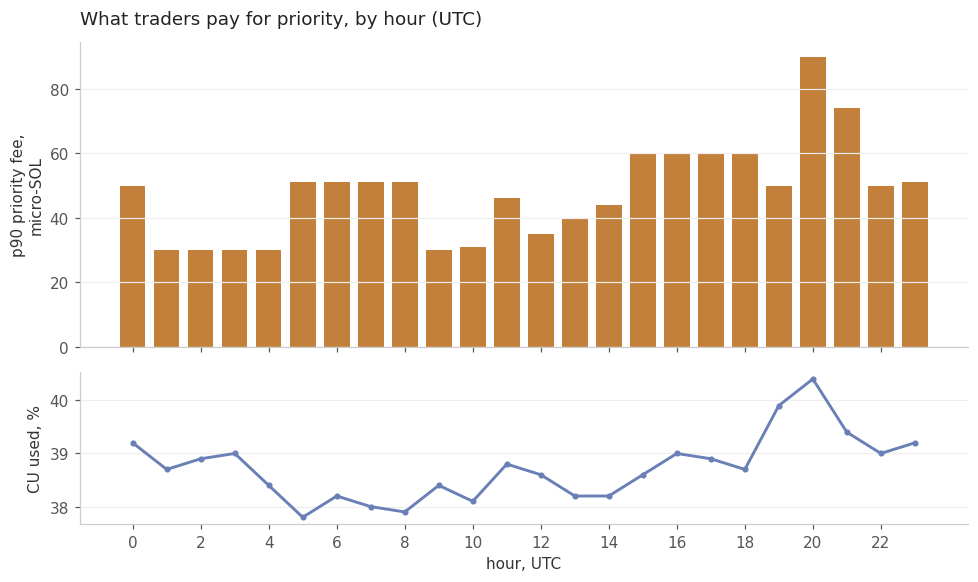

In [ ]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.4), sharex=True,                             gridspec_kw={"height_ratios": [2, 1]})a1.bar(df["hour_utc"], df["p90_priority_sol"] * 1e6)a1.set_ylabel("p90 priority fee,\nmicro-SOL")a2.plot(df["hour_utc"], df["avg_cu_used_pct"], marker="o", ms=3)a2.set_ylabel("CU used, %")a2.set_xlabel("hour, UTC")

The p90 bid roughly triples between the quiet early hours and the US session.Compute-unit utilisation, meanwhile, barely moves: traders are buying positionin the block, not doing more work.The median rounds to zero at six decimals, which is its own finding — mosttransactions on this venue submit almost no priority fee at all.

## 4. Who is actually sending the flow`parent_program` is the program that invoked the swap instruction. An emptyvalue is also the column default, so it covers both a genuinely direct call anda row where the caller could not be determined.

In [ ]:
df = client.query_df("""SELECT    if(parent_program = '', 'direct or unattributed', parent_program) AS caller,    count()                                                          AS swaps,    round(sum(quote_token_amount) / 1e9, 1)                          AS sol_volume,    round(count() / sum(count()) OVER () * 100, 1)                   AS pct_of_swapsFROM pumpswap_all_swapsWHERE block_time > now() - INTERVAL 7 DAY  AND quote_token = 'So11111111111111111111111111111111111111112'GROUP BY callerORDER BY swaps DESCLIMIT 20""")df

caller,swaps,sol_volume,pct_of_swaps
direct or unattributed,90892560,18190070.6,89.6
JUP6LkbZbjS1jKKwapdHNy74zcZ3tLUZoi5QNyVTaV4,3270090,1738499.6,3.2
FLASHX8DrLbgeR8FcfNV1F5krxYcYMUdBkrP1EPBtxB9,1980662,990798.1,2.0
DF1ow4tspfHX9JwWJsAb9epbkA8hmpSEAtxXy1V27QBH,1721238,1421780.1,1.7
6Vo3245eszAb5wuqEMw8mGdbfRUdKbHhDHP5LcaGuTAB,1551022,762962.4,1.5
proVF4pMXVaYqmy4NjniPh4pqKNfMmsihgd4wdkCX3u,415614,435832.2,0.4
MAyhSmzXzV1pTf7LsNkrNwkWKTo4ougAJ1PPg47MD4e,87520,15165.3,0.1
T1TANpTeScyeqVzzgNViGDNrkQ6qHz9KrSBS4aNXvGT,82625,36098.4,0.1
7obtMdiXQaLCao2mCRzsanxRusUH8QAz8eT5PJyUTHFQ,78937,8364.2,0.1
3s1rAymURnacreXreMy718GfqW6kygQsLNka1xDyW8pC,75324,2276.6,0.1


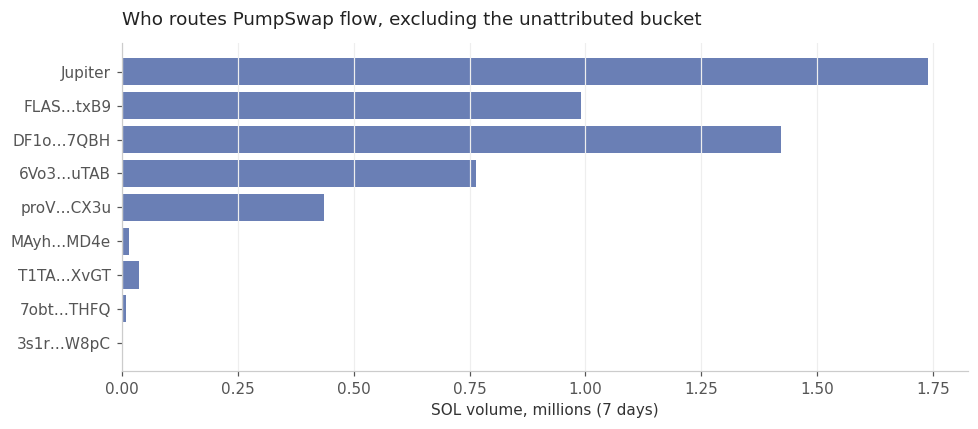

In [ ]:
r = df.iloc[1:].copy()        # exclude the direct-or-unattributed bucketr["label"] = r["caller"].str[:4] + "…" + r["caller"].str[-4:]r.loc[r["caller"].str.startswith("JUP6"), "label"] = "Jupiter"ax = r.plot.barh(x="label", y="sol_volume", figsize=(9, 4.0), legend=False)ax.set_xlabel("SOL volume, millions (7 days)")

Just under 90% of swap rows carry no caller. Of the rest, Jupiter is the singlelargest router at 1.74M SOL over seven days, followed by a set of programs whosevolume per swap is far higher than Jupiter's — a different kind of participantusing the same venue.Note that these are swap instructions rather than transactions: a routed tradethat touches several pools appears once per hop.

---Read-only credentials, $200/month per chain, one-week free trial.[Request one](https://docs.google.com/forms/d/e/1FAIpQLSduVHVt51hEMGD2847Yj0rQTy1U5ogIgHPHutKyZth0ALhrwA/viewform)or see the [docs](https://onchaindivers.com/).